# **Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

# **Constants**

In [2]:
sns.set_theme(style="whitegrid", palette="Dark2")

In [3]:
SEED = 10
RESULT_SCORES = [-1, 60, 100]
RESULT_LABELS = ['Fail', 'Pass']
SCORES = [-1, 60, 70, 80, 90, 100]
GRADES = ["F", "D", "C", "B", "A"]
SCORES_LONG = [-1, 60, 63, 67, 70, 73, 77, 80, 83, 87, 90, 93, 97, 100]
GRADES_LONG = ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+']

# **Data Exploration**

In [4]:
data = pd.read_csv('StudentsPerformance.csv')
print(data.isna().sum().sum())
data

0


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
for col in data.columns[:-3]: print(col, data[col].unique(), sep=' : ')

gender : ['female' 'male']
race/ethnicity : ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch : ['standard' 'free/reduced']
test preparation course : ['none' 'completed']


# **Data Processing**

In [7]:
data['gender'] = data['gender'].astype('category')
data['race/ethnicity'] = pd.Categorical(data['race/ethnicity'], categories=['group E', 'group D', 'group C', 'group B', 'group A'][::-1], ordered=True)
data['parental level of education'] = pd.Categorical(data['parental level of education'],
                                                     categories=['some high school', 'high school', "bachelor's degree", 'some college', "associate's degree", "master's degree"],
                                                     ordered=True)
data['lunch'] = pd.Categorical(data['lunch'], categories=['free/reduced', 'standard'], ordered=True)
data['test preparation course'] = pd.Categorical(data['test preparation course'], categories=['none', 'completed'], ordered=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       1000 non-null   category
 1   race/ethnicity               1000 non-null   category
 2   parental level of education  1000 non-null   category
 3   lunch                        1000 non-null   category
 4   test preparation course      1000 non-null   category
 5   math score                   1000 non-null   int64   
 6   reading score                1000 non-null   int64   
 7   writing score                1000 non-null   int64   
dtypes: category(5), int64(3)
memory usage: 29.2 KB


# **Data Analysis**

In [8]:
data.groupby('gender').mean('math score')

C:\Users\korda\AppData\Local\Temp\ipykernel_10080\1278067521.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('gender').mean('math score')


,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


## Test scores correlation

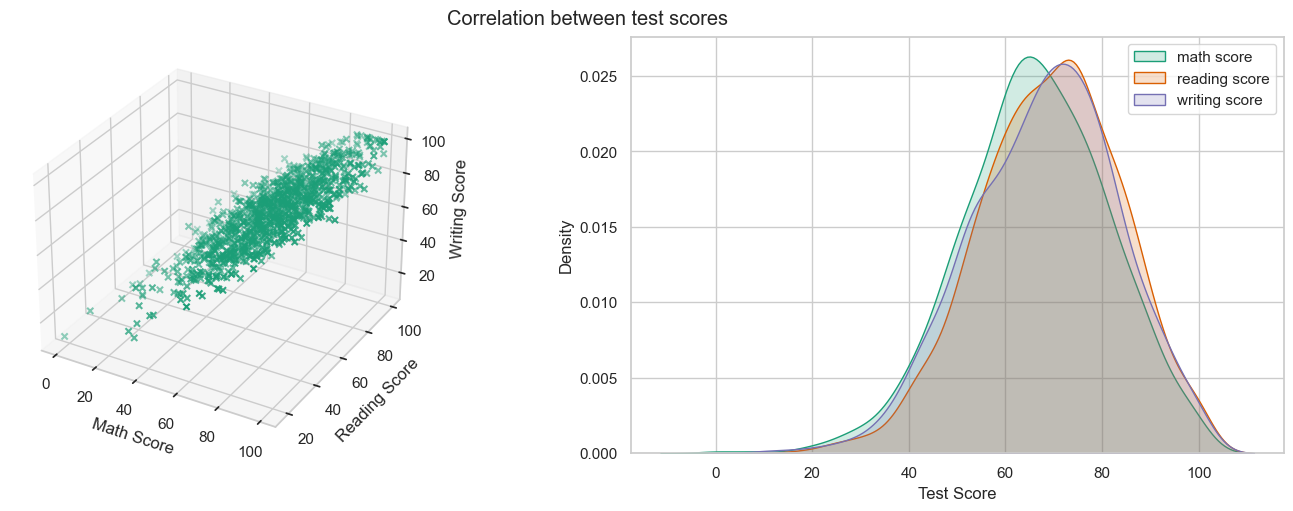

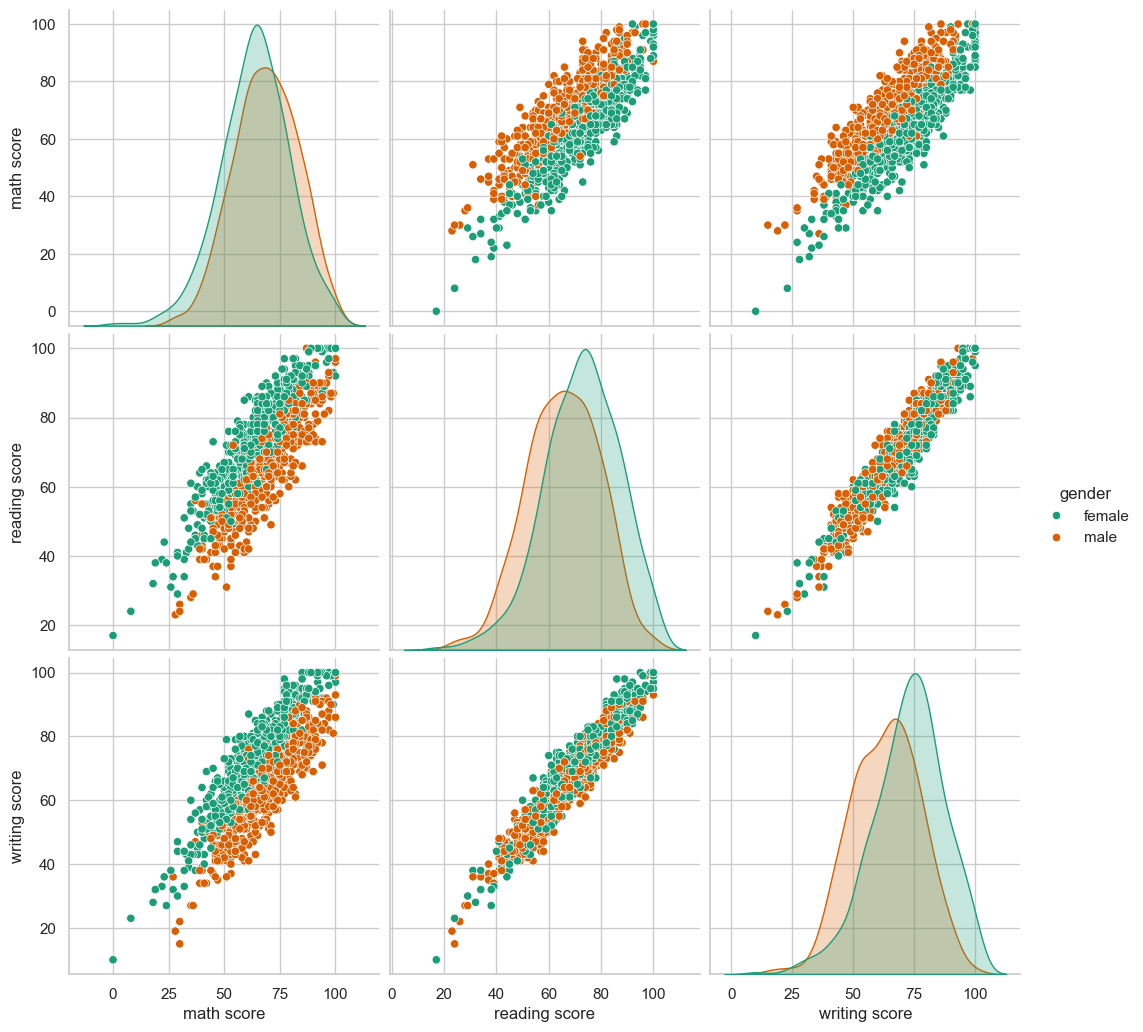

In [9]:
def view_score_correlation(data, cols, size=(14,5), title=''):
    fig, ax = plt.subplot_mosaic([['A', 'B']], figsize=size, layout='constrained', per_subplot_kw={'A': {'projection': '3d'}})
    ax['A'].scatter(data[cols[0]], data[cols[1]], data[cols[2]], marker='x')
    ax['A'].set_xlabel('Math Score')
    ax['A'].set_ylabel('Reading Score')
    ax['A'].set_zlabel('Writing Score')
    for x in cols:
        sns.kdeplot(ax=ax['B'], data=data, x=x, fill=True, label=x, alpha=.2)
    ax['B'].set_xlabel('Test Score')
    ax['B'].legend()
    fig.suptitle(title)
view_score_correlation(data, data.columns[-3:], title='Correlation between test scores')
sns.pairplot(pd.concat([data['gender'], data[data.columns[-3:]]], axis=1), hue='gender', height=3.5)


## Ethnicity in relation to economic inequality

Text(0.5, 0.98, 'Ethnicity in relation to economic inequality')

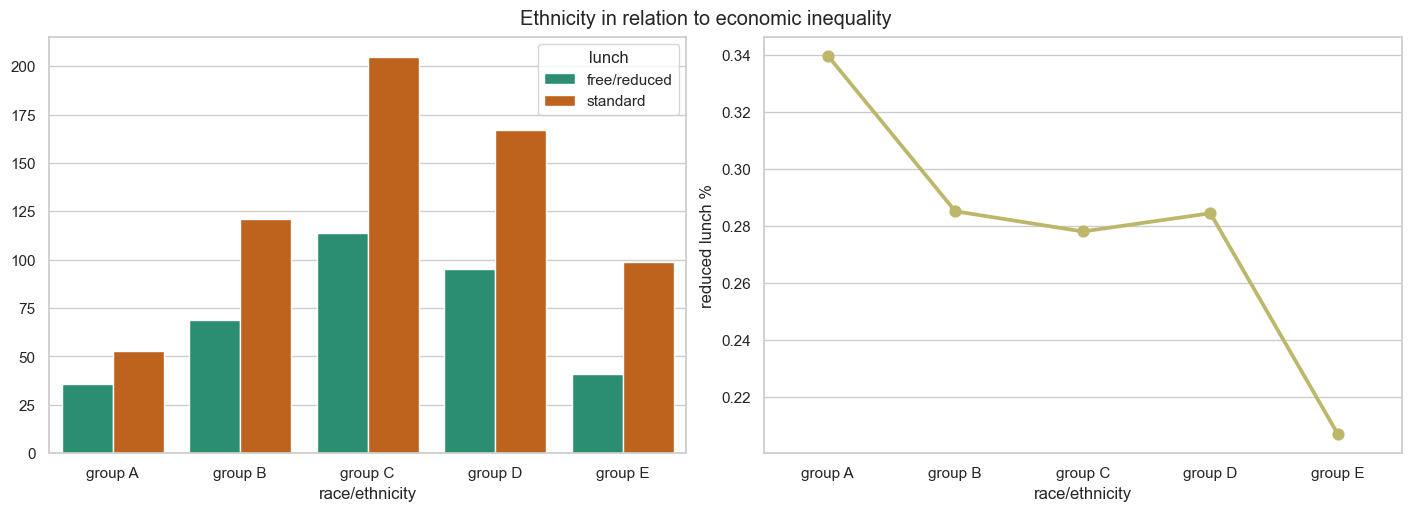

In [10]:
eth_eco = pd.pivot_table(data, index='race/ethnicity', columns='lunch', aggfunc='size', observed=False)
eth_eco['diff'] = eth_eco['standard'] - eth_eco['free/reduced']
eth_eco['percentage'] = eth_eco['free/reduced'] / (eth_eco.sum(axis=1))

fig, ax = plt.subplots(1,2, figsize=(14,5), layout='constrained')
sns.countplot(ax=ax[0], data=data, x='race/ethnicity', hue='lunch')
sns.pointplot(ax=ax[1], data=eth_eco['percentage'], color='darkkhaki')
ax[0].set_ylabel('')
ax[1].set_ylabel('reduced lunch %')
fig.suptitle('Ethnicity in relation to economic inequality')

## Economic status' influence on test scores

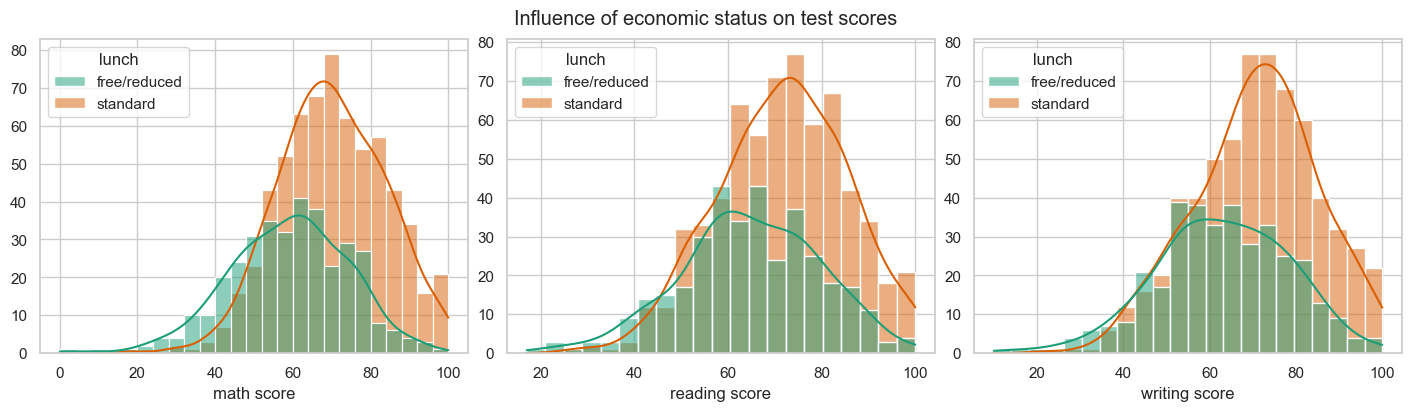

In [11]:
def view_influence_on_score(data, hue, size=(14,4), kde=True, bw=1, countplot=False, title=''):
    fig, ax = plt.subplots(1,3, figsize=size, layout='constrained')
    if not countplot:
        for i, xi in enumerate(['math score', 'reading score', 'writing score']):
            sns.histplot(ax=ax[i], data=data, x=xi, hue=hue, kde=kde, kde_kws={'bw_adjust': bw})
            ax[i].set_ylabel('')
    else : 
        for i, xi in enumerate(['math score', 'reading score', 'writing score']):
            sns.countplot(ax=ax[i], data=data, x=xi, hue=hue)
            ax[i].set_ylabel('')
    fig.suptitle(title)
view_influence_on_score(data, 'lunch', title='Influence of economic status on test scores')

## Influence of the parents' education level 
### i. on students completing the test preparation course

C:\Users\korda\AppData\Local\Temp\ipykernel_10080\1488213345.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  edu_test = pd.pivot_table(data=data, index='parental level of education', columns='test preparation course', aggfunc='size')


Text(0.5, 0.98, 'Test preparation course completion per parental education level')

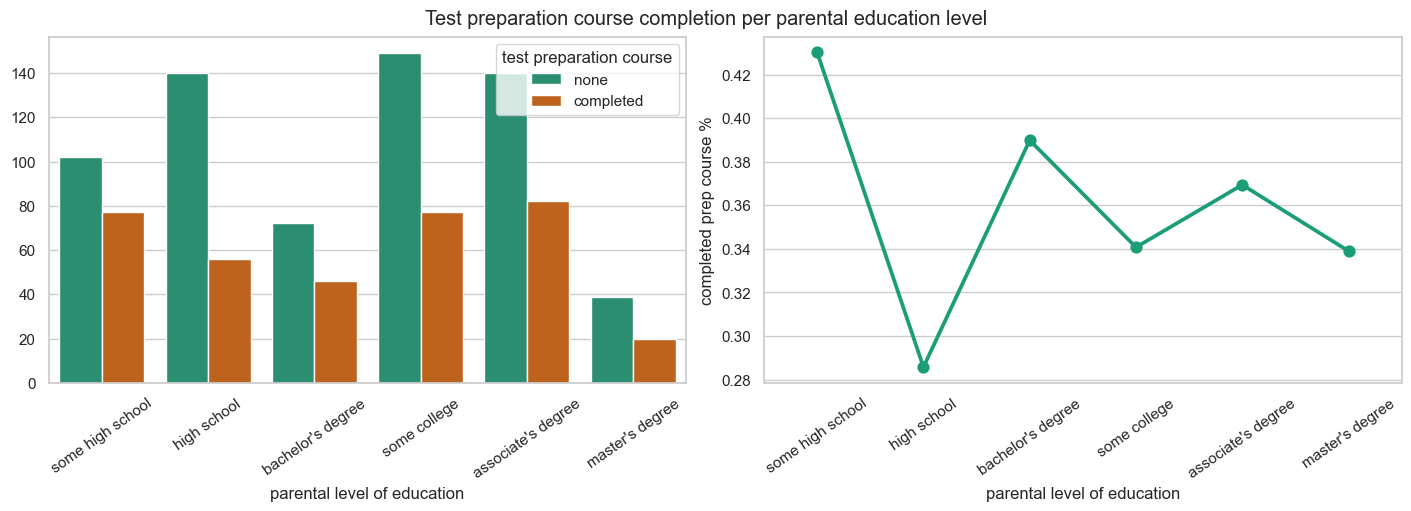

In [12]:
edu_test = pd.pivot_table(data=data, index='parental level of education', columns='test preparation course', aggfunc='size')
edu_test['perc'] = edu_test['completed'] / (edu_test['none'] + edu_test['completed'])

fig, ax = plt.subplot_mosaic([['A', 'B']], figsize=(14,5), layout='constrained')
sns.countplot(ax=ax['A'], data=data, x='parental level of education', hue='test preparation course')
sns.pointplot(ax=ax['B'], data=edu_test['perc'])
ax['A'].tick_params(axis='x', rotation=35)
ax['A'].set_ylabel('')
ax['B'].tick_params(axis='x', rotation=35)
ax['B'].set_ylabel('completed prep course %')
fig.suptitle('Test preparation course completion per parental education level')

### ii. on test scores

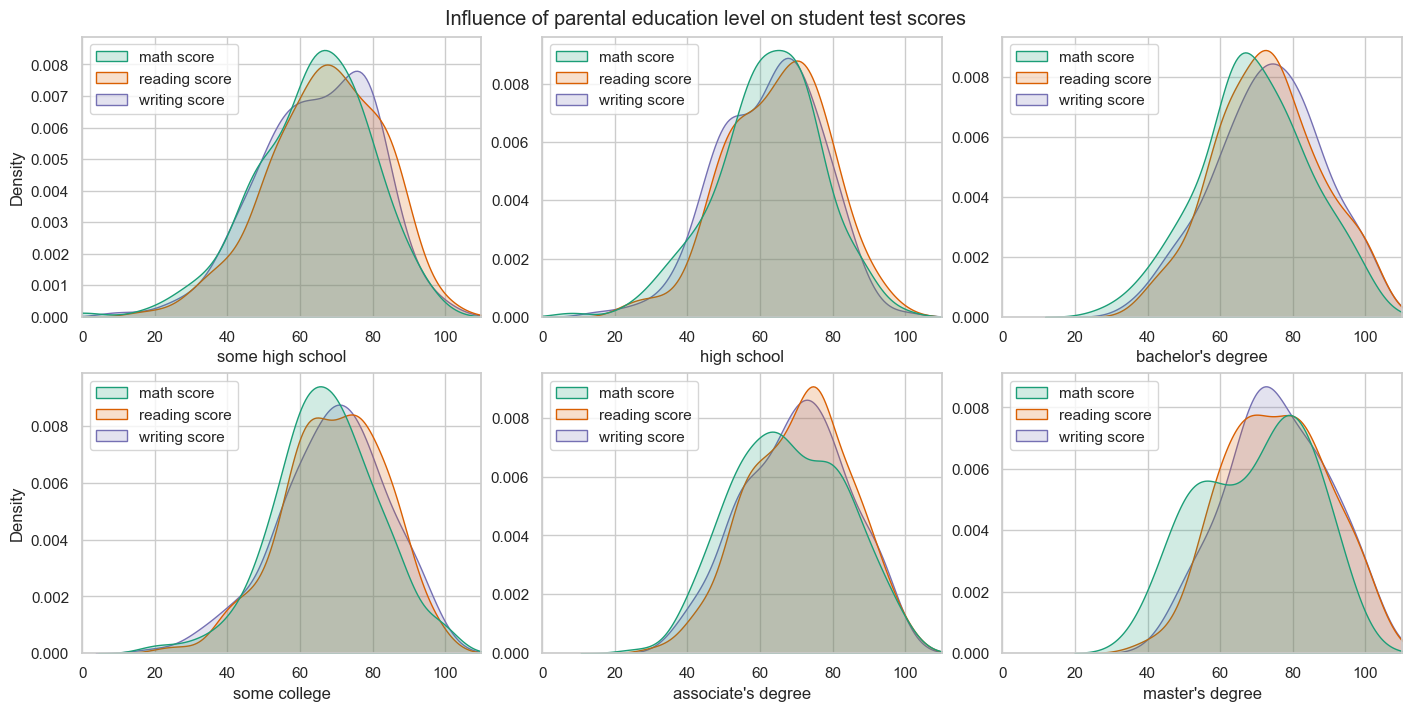

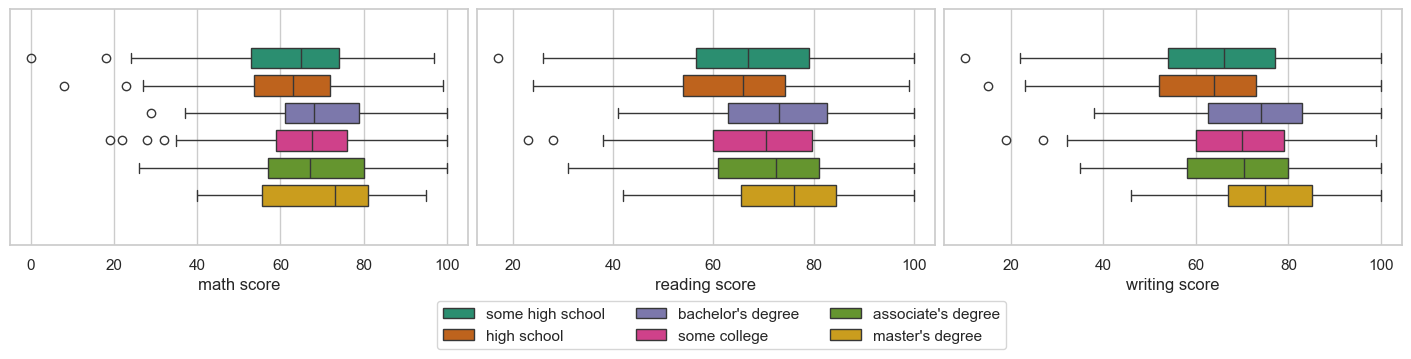

In [13]:
def view_influence_on_score_boxes(data, x, hue, size=[14,3], width=.7, gap=.25, title=''):
    fig, ax = plt.subplots(1,3, figsize=size, layout='constrained')
    for i,xi in enumerate(x):
        sns.boxplot(ax=ax[i], data=data, x=xi, hue=hue, width=width, gap=gap)
        ax[i].legend_.remove()
    handles, legend = ax[i].get_legend_handles_labels()
    fig.legend(handles, legend, bbox_to_anchor=(.72, .01), ncol=3)
    fig.suptitle(title)
    
def view_influence_on_score_t(data, col, r=2, c=3, size=[14,7], title=''):
    fig, ax = plt.subplots(r,c, figsize=size, layout='constrained')
    ranges = [(i,j) for i in range(r) for j in range(c)]
    for (i,j), cat in zip(ranges, data[col].cat.categories):
        sns.kdeplot(ax=ax[(i,j) if r>1 else j], data=data[data[col]==cat], fill=True, alpha=.2)
        ax[(i,j) if r>1 else j].set_xlabel(cat)
        ax[(i,j) if r>1 else j].set_xlim(0,110)
        if j>0 : ax[(i,j) if r>1 else j].set_ylabel('')
    fig.suptitle(title)


view_influence_on_score_t(data, 'parental level of education', title='Influence of parental education level on student test scores')
view_influence_on_score_boxes(data, x=data.columns[-3:], hue='parental level of education')

## Importance of the test preparation course

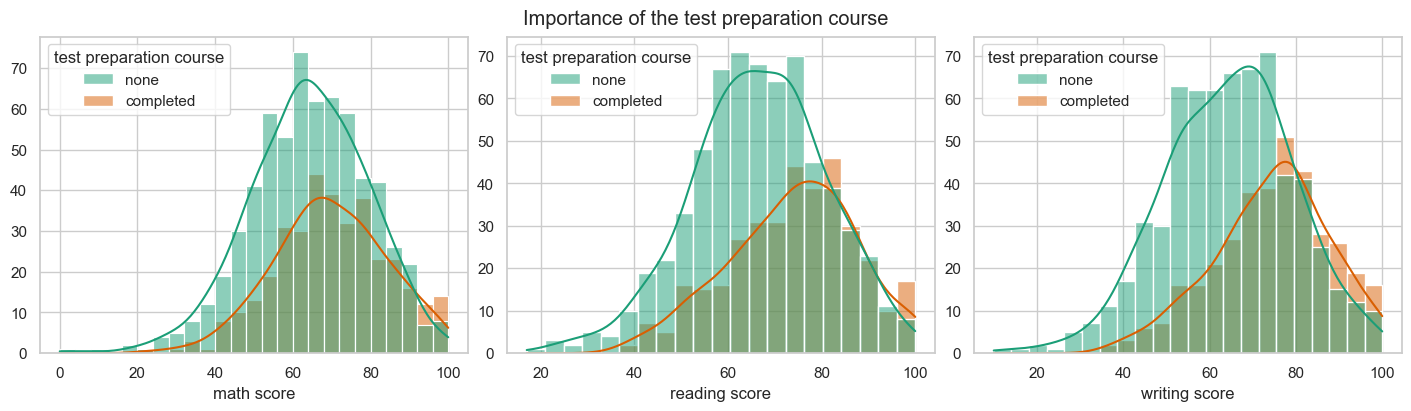

In [14]:
view_influence_on_score(data, hue='test preparation course', title='Importance of the test preparation course') 

# **Data Analysis by Results**

In [15]:
def make_target_categorical(data, cols, bins=SCORES, labels=GRADES):
    d = data.copy()
    for col in cols:
        d[col] = pd.cut(d[col], bins=bins, labels=labels)
    return d

def make_numerical(data, cols):
    d = data.copy()
    for col in cols:
        d[col] = d[col].cat.codes
    return d

data_res = make_target_categorical(data, data.columns[-3:], bins=RESULT_SCORES, labels=RESULT_LABELS)
data_res.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,Pass,Pass,Pass
1,female,group C,some college,standard,completed,Pass,Pass,Pass
2,female,group B,master's degree,standard,none,Pass,Pass,Pass
3,male,group A,associate's degree,free/reduced,none,Fail,Fail,Fail
4,male,group C,some college,standard,none,Pass,Pass,Pass


In [16]:
pd.pivot_table(data=data_res, index='gender', columns='test preparation course', aggfunc='size', observed=False)

test preparation course,none,completed
gender,,
female,334,184
male,308,174


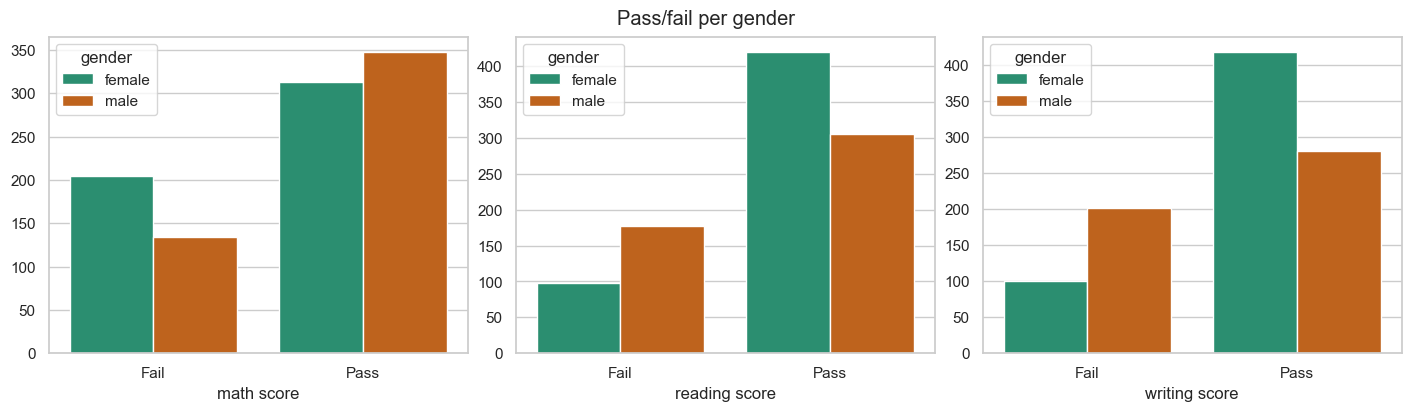

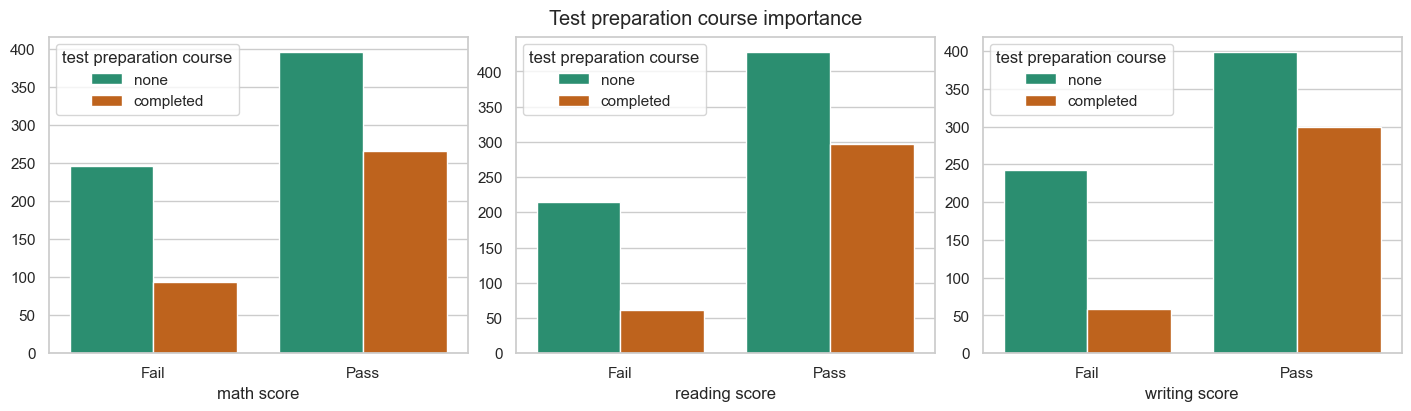

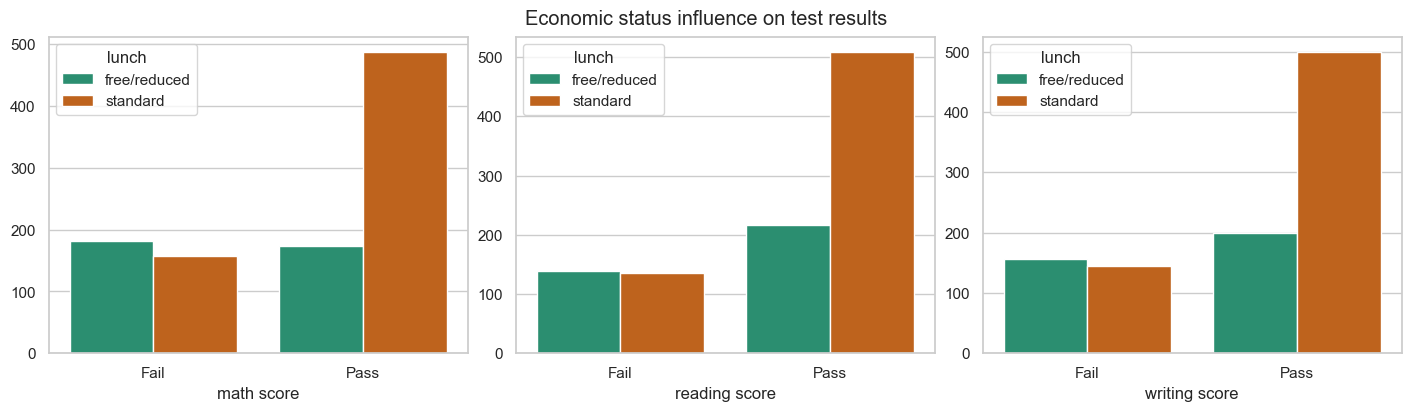

In [17]:
view_influence_on_score(data_res, hue='gender', countplot=True, title='Pass/fail per gender')
view_influence_on_score(data_res, hue='test preparation course', countplot=True, title='Test preparation course importance')
view_influence_on_score(data_res, hue='lunch', countplot=True, title='Economic status influence on test results')

C:\Users\korda\AppData\Local\Temp\ipykernel_10080\1812023343.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  edu_res_m = pd.pivot_table(data=data_res, index='parental level of education', columns='math score', aggfunc='size')


Text(0.5, 0.98, 'Influence of parental education level on test results')

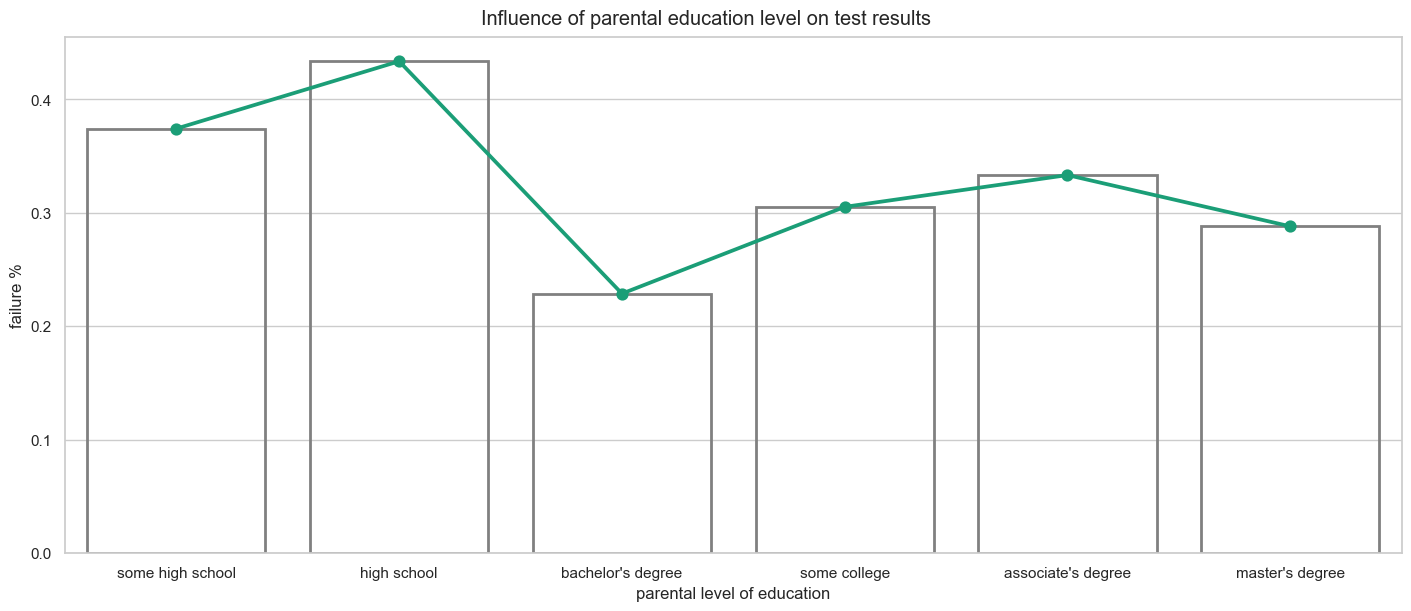

In [18]:
edu_res_m = pd.pivot_table(data=data_res, index='parental level of education', columns='math score', aggfunc='size')
edu_res_m['percentage'] = edu_res_m['Fail']/edu_res_m.sum(axis=1)

fig, ax = plt.subplots(figsize=(14,6), layout='constrained')
sns.barplot(data=edu_res_m['percentage'], linewidth=2, edgecolor=".5", facecolor=(0, 0, 0, 0))
sns.pointplot(data=edu_res_m['percentage'])
ax.set_ylabel('failure %')
fig.suptitle('Influence of parental education level on test results')

# **Data Analysis by Grades**

In [19]:
data_cat = make_target_categorical(data, data.columns[-3:])

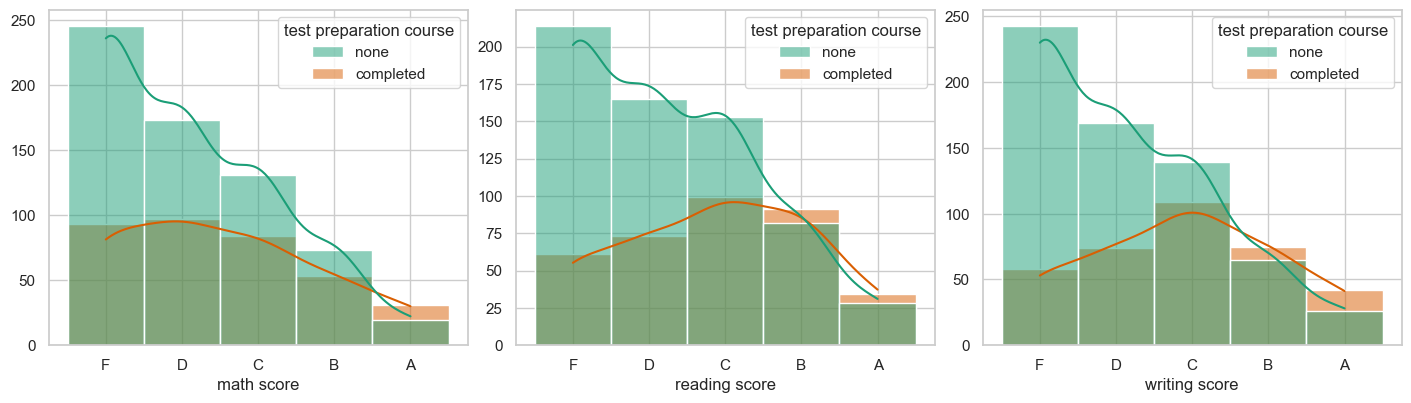

In [20]:
view_influence_on_score(data_cat, hue='test preparation course', bw=1.4)

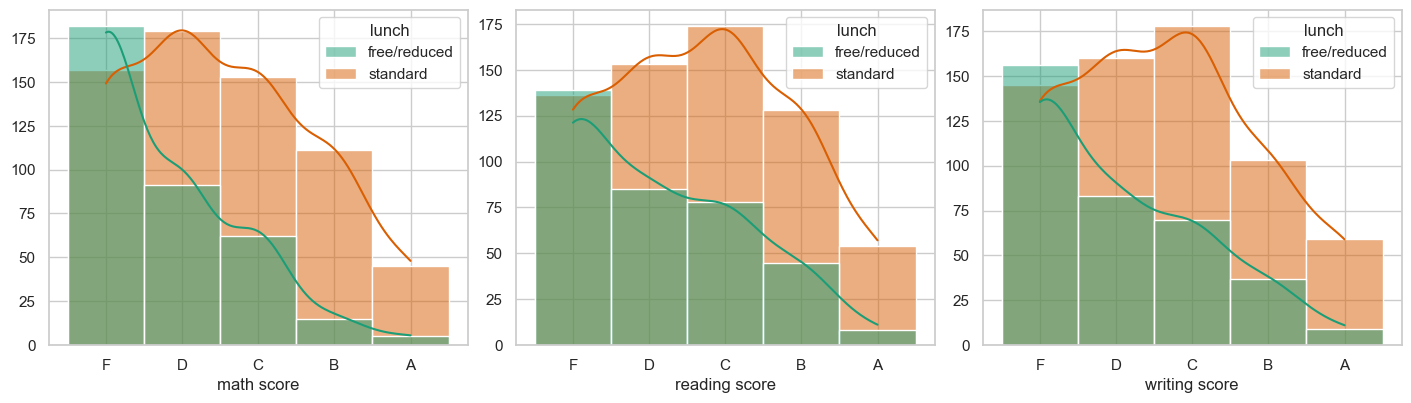

In [21]:
view_influence_on_score(data_cat, hue='lunch', bw=1.4)

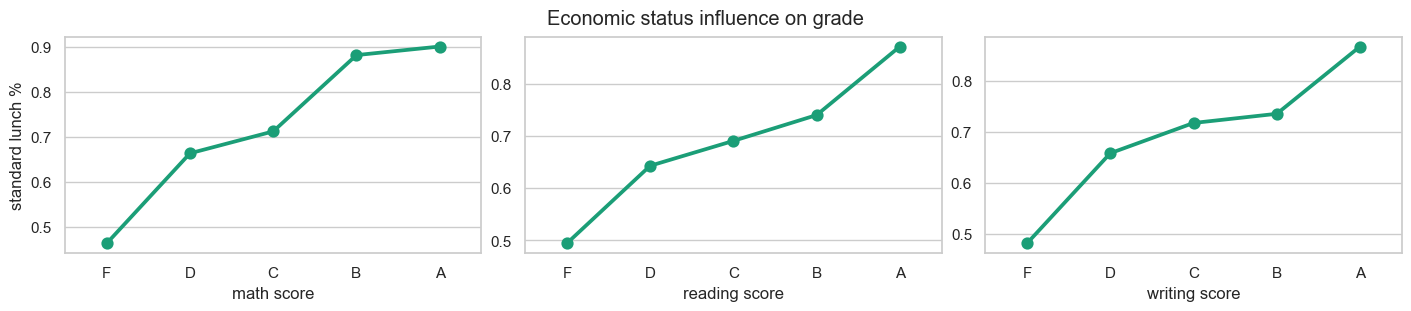

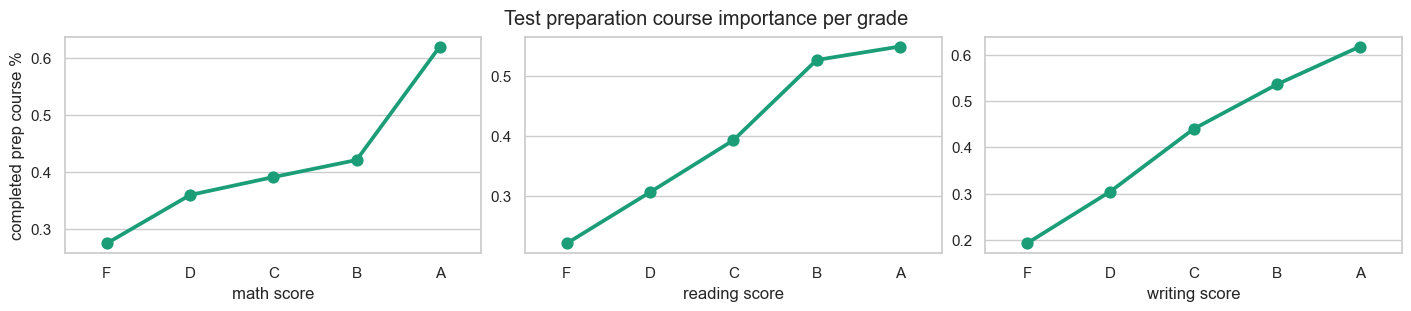

In [22]:
def view_influence_on_grade(data, col, size=[14,3], neg=True, title='', ylabel=''):
    fig, ax = plt.subplots(1,3,figsize=size, layout='constrained')
    for i,idx in enumerate(['math score', 'reading score', 'writing score']):
        tab = pd.pivot_table(data=data, index=idx, columns=col, aggfunc='size', observed=False)
        tab['precentage '+tab.columns[1-neg]] = tab[tab.columns[1-neg]] / tab.sum(axis=1)
        sns.pointplot(ax=ax[i], data=tab['precentage '+tab.columns[1-neg]])
        if i>0: ax[i].set_ylabel('')
    if ylabel : ax[0].set_ylabel(ylabel)
    fig.suptitle(title)


view_influence_on_grade(data_cat, 'lunch', neg=False, title='Economic status influence on grade', ylabel='standard lunch %')
view_influence_on_grade(data_cat, 'test preparation course', neg=False, title='Test preparation course importance per grade', 
                        ylabel='completed prep course %')

## Grade analysis summary

C:\Users\korda\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:96: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)


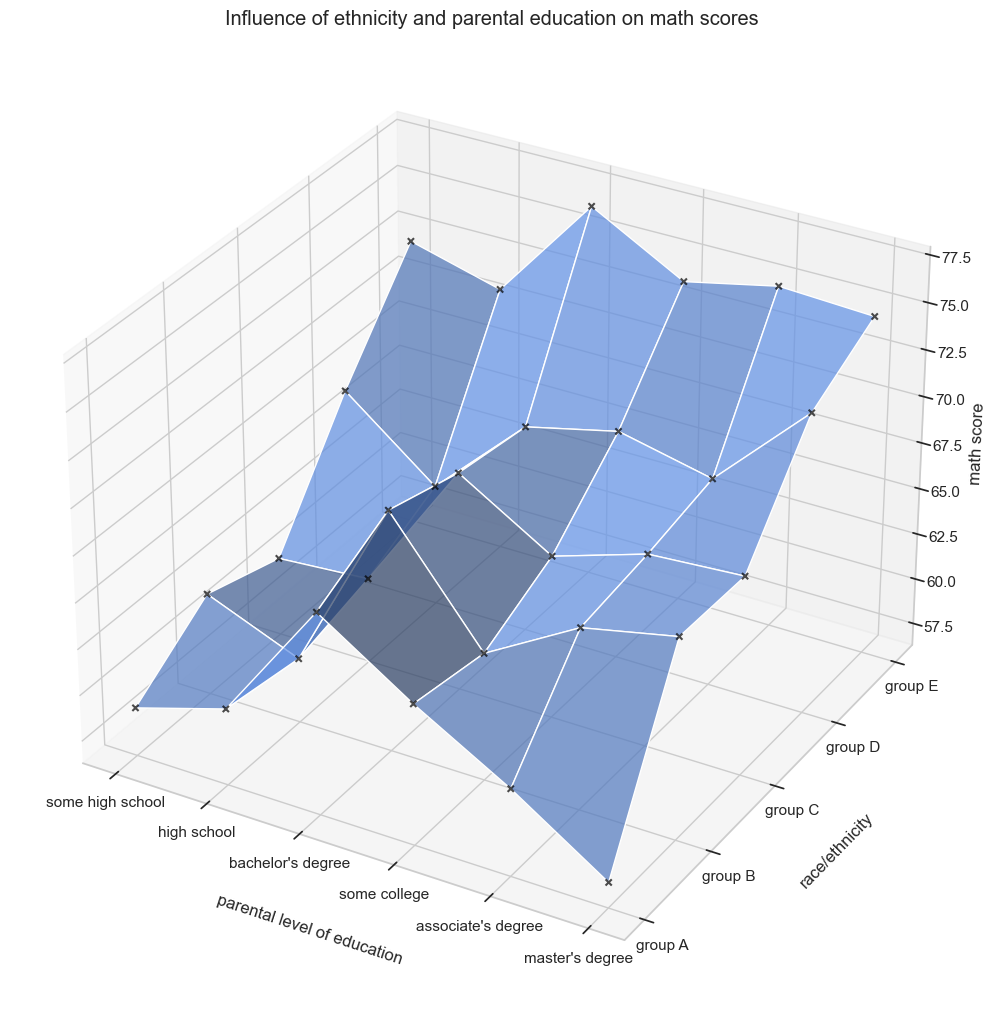

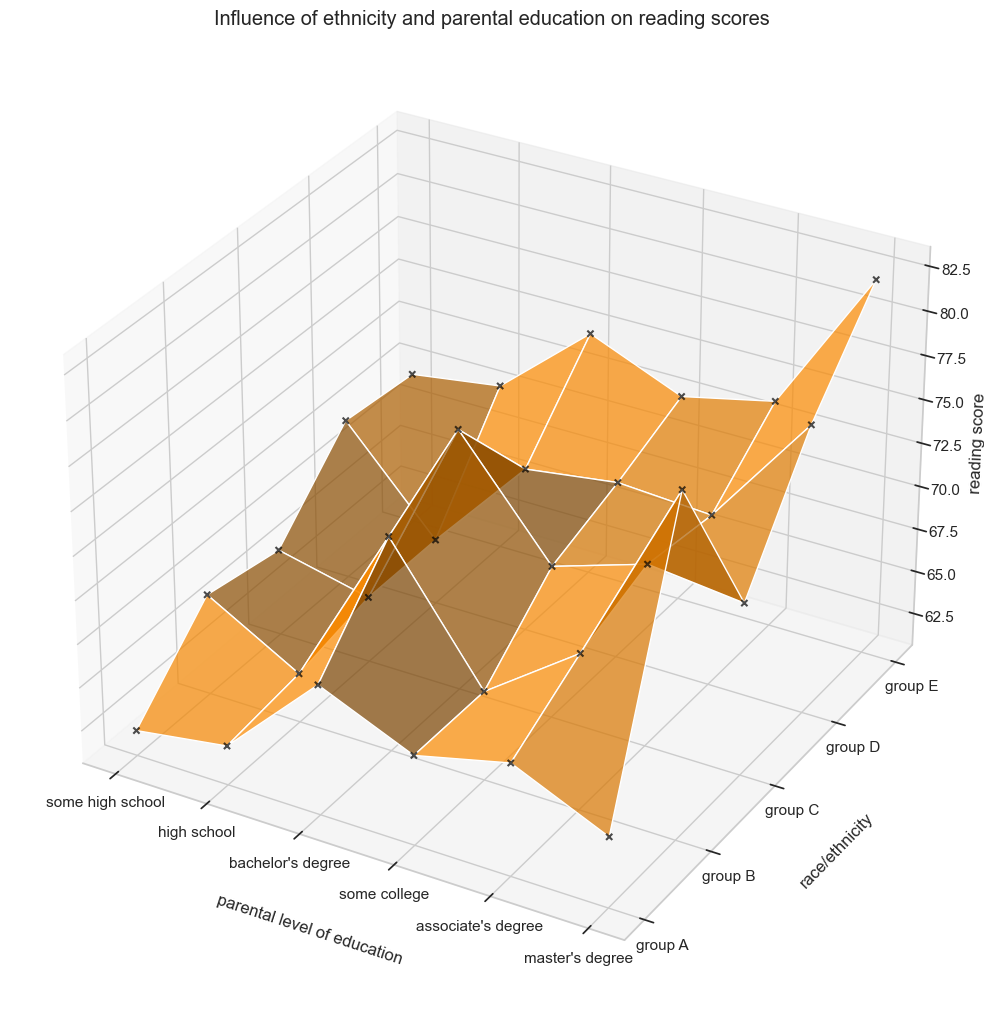

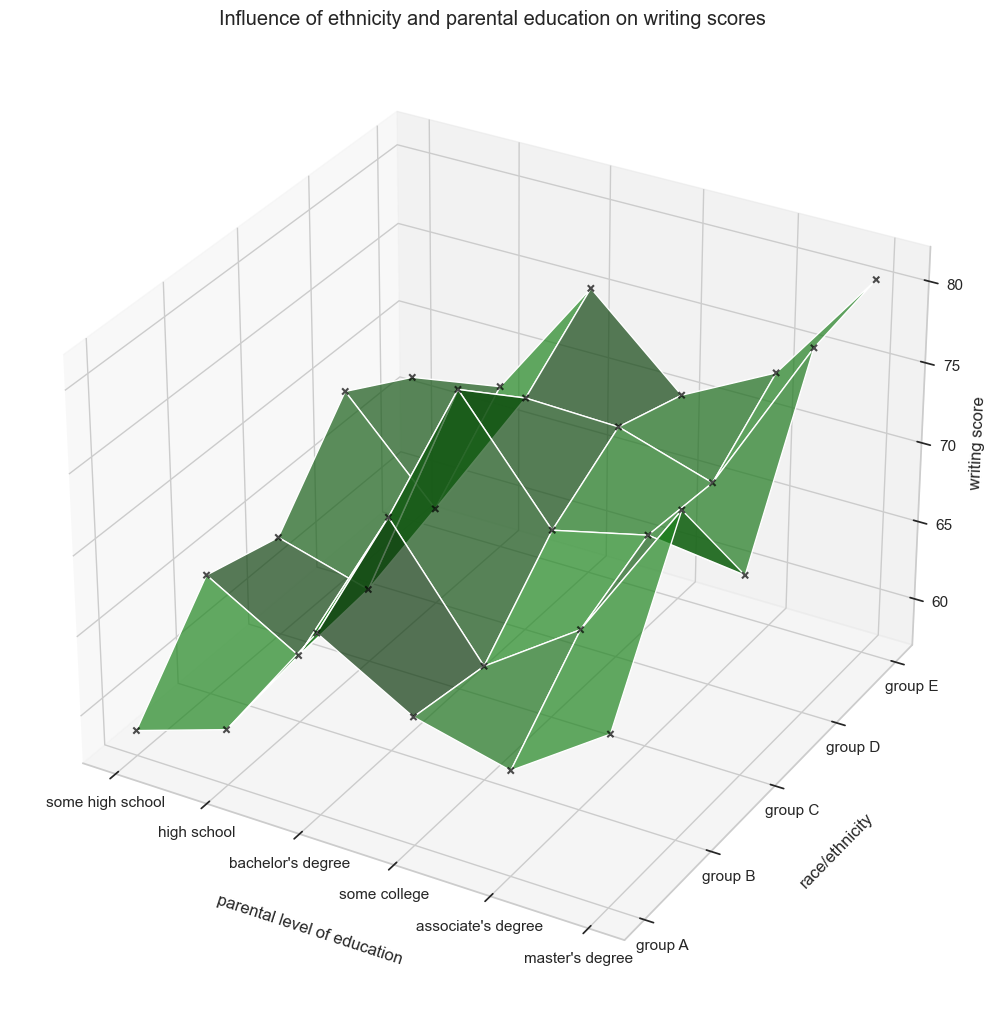

In [ ]:
def view_3D_plot(data, index, columns, values, aggfunc='mean', size=(14,9), color='darkkhaki', title=''):
    tab = pd.pivot_table(data, index=index, columns=columns, values=values, aggfunc=aggfunc, observed=False)
    fig, ax = plt.subplots(figsize=(10,10), layout='constrained', subplot_kw={'projection': '3d'})
    ax_x, ax_y = np.meshgrid(np.arange(len(tab.index)), np.arange(len(tab.columns)))
    ax_x, ax_y = np.meshgrid(np.arange(len(tab.index)), np.arange(len(tab.columns)))
    ax.plot_surface(ax_x, ax_y, tab.T, alpha=.7, color=color)
    ax.scatter(ax_x, ax_y, tab.T, alpha=.7, color='black', marker='x')
    ax.set_xticks(np.arange(len(tab.index))); ax.set_yticks(np.arange(len(tab.columns)))
    ax.set_xlabel(index, labelpad=20)
    ax.set_ylabel(columns, labelpad=20)
    ax.set_zlabel(values)
    _, _ = ax.set_xticklabels(tab.index), ax.set_yticklabels(tab.columns)
    fig.suptitle(title)

view_3D_plot(data, 'parental level of education', columns='race/ethnicity', values='math score', color='cornflowerblue',
             title='Influence of ethnicity and parental education on math scores')

In [ ]:
view_3D_plot(data, 'parental level of education', columns='race/ethnicity', values='reading score', color='darkorange',
             title='Influence of ethnicity and parental education on reading scores')

In [ ]:
view_3D_plot(data, 'parental level of education', columns='race/ethnicity', values='writing score', color='forestgreen',
             title='Influence of ethnicity and parental education on writing scores')

# **Modeling**
*Finding the features with the most influence on the test score*

## Feature importance for passing

In [24]:
def find_feature_importance(features, target, size=(10,2), oversample=False, title=''):
    features = make_numerical(features, features.columns)
    if oversample : 
        sm = SMOTE(random_state=SEED) 
        features, target = sm.fit_resample(features, target)
    model = DecisionTreeClassifier()
    model.fit(features, target)
    report = metrics.classification_report(target, model.predict(features))
    sorted_feat_index = [i for _,i in sorted([(v,i) for i,v in enumerate(model.feature_importances_)], reverse=True)]
    sorted_feats = [features.columns[i] for i in sorted_feat_index]
    fig, ax = plt.subplots(figsize=size, layout='constrained')
    sns.barplot(y=sorted_feats, x=sorted(model.feature_importances_, reverse=True))
    fig.suptitle(title)
    return report 

-------------------- Math Score --------------------
               precision    recall  f1-score   support

        Fail       0.72      0.85      0.78       661
        Pass       0.82      0.66      0.73       661

    accuracy                           0.76      1322
   macro avg       0.77      0.76      0.76      1322
weighted avg       0.77      0.76      0.76      1322

-------------------- Reading Score --------------------
               precision    recall  f1-score   support

        Fail       0.75      0.84      0.79       725
        Pass       0.82      0.71      0.76       725

    accuracy                           0.78      1450
   macro avg       0.78      0.78      0.77      1450
weighted avg       0.78      0.78      0.77      1450

-------------------- Writing Score --------------------
               precision    recall  f1-score   support

        Fail       0.75      0.86      0.80       699
        Pass       0.83      0.72      0.77       699

    accuracy  

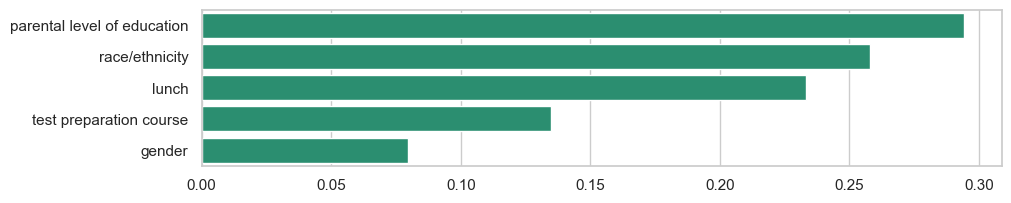

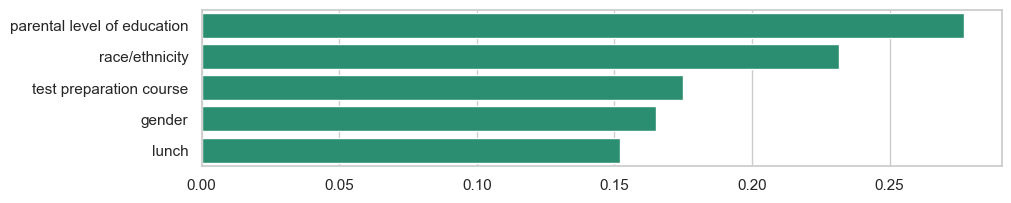

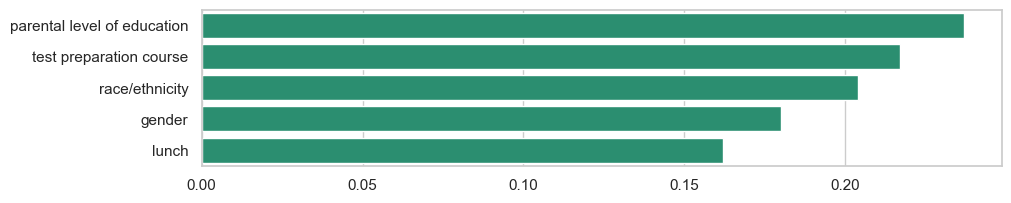

In [25]:
print(f"{'-'*20} Math Score {'-'*20}\n",
       find_feature_importance(data_res[data.columns[:-3]], data_res['math score'], oversample=True))
print(f"{'-'*20} Reading Score {'-'*20}\n",
      find_feature_importance(data_res[data.columns[:-3]], data_res['reading score'], oversample=True))
print(f"{'-'*20} Writing Score {'-'*20}\n",
      find_feature_importance(data_res[data.columns[:-3]], data_res['writing score'], oversample=True))

## Feature importance per grade

-------------------- Math Score --------------------
               precision    recall  f1-score   support

           A       0.56      0.86      0.68       339
           B       0.51      0.57      0.54       339
           C       0.50      0.49      0.49       339
           D       0.49      0.42      0.45       339
           F       0.68      0.33      0.45       339

    accuracy                           0.54      1695
   macro avg       0.55      0.54      0.52      1695
weighted avg       0.55      0.54      0.52      1695

-------------------- Reading Score --------------------
               precision    recall  f1-score   support

           A       0.63      0.81      0.71       275
           B       0.51      0.64      0.57       275
           C       0.45      0.50      0.47       275
           D       0.53      0.33      0.41       275
           F       0.59      0.43      0.50       275

    accuracy                           0.54      1375
   macro avg       0

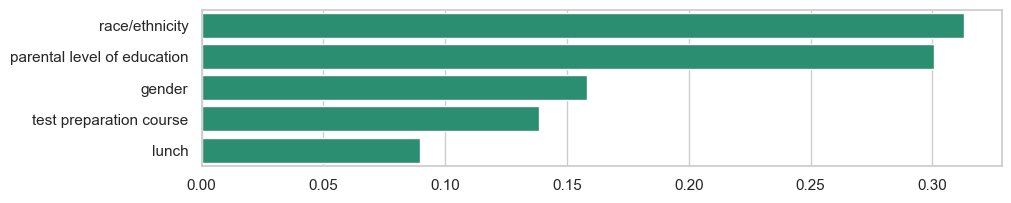

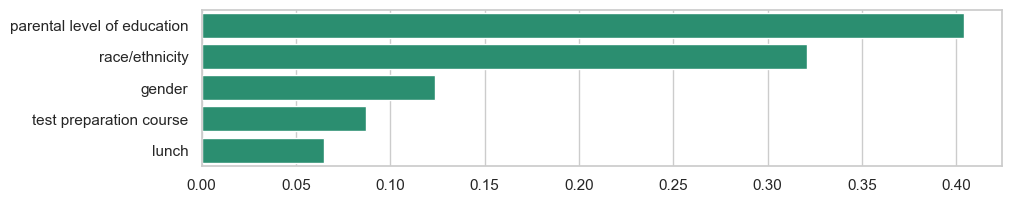

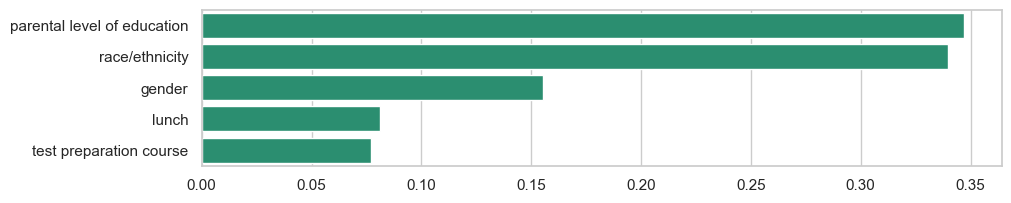

In [26]:
print(f"{'-'*20} Math Score {'-'*20}\n",
       find_feature_importance(data_cat[data.columns[:-3]], data_cat['math score'], oversample=True))
print(f"{'-'*20} Reading Score {'-'*20}\n",
      find_feature_importance(data_cat[data.columns[:-3]], data_cat['reading score'], oversample=True))
print(f"{'-'*20} Writing Score {'-'*20}\n",
      find_feature_importance(data_cat[data.columns[:-3]], data_cat['writing score'], oversample=True))